# Circuit Verification Demo

Verifies the four QASM figure pairs used in the PhasePoly paper with two methods (both from `src.circuit_verification`):

- **Qiskit** — `Operator.equiv` unitary check (≤ 8 qubits).
- **MQT QCEC** — formal equivalence check (any size).

In [1]:
from pathlib import Path
import sys

try:
    from IPython.display import display
except ImportError:
    display = print

from qiskit import QuantumCircuit

# Resolve repo root so the notebook works whether launched from this folder or its parent.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    candidates = [c for c in PROJECT_ROOT.iterdir() if c.is_dir() and (c / "src" / "phasepoly.py").exists()]
    if not candidates:
        raise RuntimeError(f"Cannot locate PhasePoly src/ from {PROJECT_ROOT}")
    PROJECT_ROOT = candidates[0]
PROJECT_ROOT = PROJECT_ROOT.resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.circuit_verification import verify_pair

DOC_DIR = PROJECT_ROOT / "docs"
METHODS = ["qiskit", "qcec"]

In [2]:
def load_doc_pair(fig_id):
    # Load docs/figX_1.qasm and docs/figX_2.qasm.
    paths = (DOC_DIR / f"fig{fig_id}_1.qasm", DOC_DIR / f"fig{fig_id}_2.qasm")
    circuits = tuple(QuantumCircuit.from_qasm_file(str(path)) for path in paths)
    return paths, circuits


def print_counts(label, circuit):
    counts = dict(circuit.count_ops())
    print(f"{label:<10} qubits={circuit.num_qubits:<2} ops={counts}")


def show_doc_pair(fig_id, labels=("(a) before", "(b) after")):
    paths, circuits = load_doc_pair(fig_id)
    for label, path, circuit in zip(labels, paths, circuits):
        print_counts(label, circuit)
        print(f"QASM: {path.relative_to(PROJECT_ROOT)}")
        display(circuit.draw("mpl", fold=-1, idle_wires=False))
    return paths, circuits


def verify_doc_pair(fig_id, timeout=60):
    paths, _ = load_doc_pair(fig_id)
    record = verify_pair(str(paths[0]), str(paths[1]), methods=METHODS, timeout=timeout)
    print_verification(record)
    return record


def print_verification(record):
    for method in METHODS:
        result = record[method]
        print(
            f"{method:>6}: {result['status']:<8} "
            f"{result['detail']}  ({result['elapsed']:.2f}s)"
        )


## Fig. 2: Phase Polynomial Optimization

The two circuits implement the same phase polynomial and the same output-basis transformation. The optimized version removes redundant parity construction while preserving functional equivalence.


(a) before qubits=3  ops={'cx': 5, 'rz': 4}
QASM: docs/fig2_1.qasm


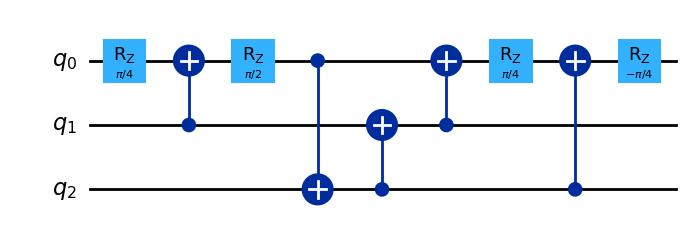

(b) after  qubits=3  ops={'cx': 4, 'rz': 2}
QASM: docs/fig2_2.qasm


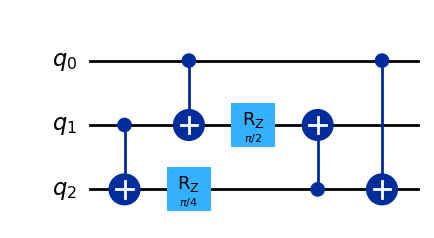

In [3]:
fig2_paths, fig2_circuits = show_doc_pair(2)


In [4]:
fig2_record = verify_doc_pair(2)


qiskit: ok       True  (0.04s)
  qcec: ok       EquivalenceCriterion.equivalent  (0.07s)


## Fig. 3: Co-optimizing `p` and `g`

Both circuits use a minimal phase-parity network for the `p` function. They differ in the cost left for the output-parity transformation `g`, so the total CNOT cost is different.


(a) lower total cost qubits=3  ops={'cx': 4, 'rz': 2, 'barrier': 1}
QASM: docs/fig3_1.qasm


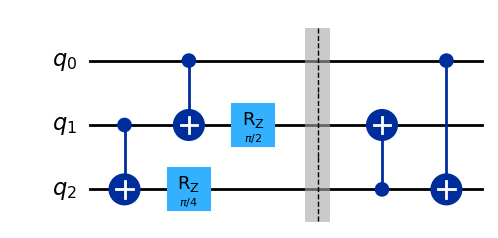

(b) higher total cost qubits=3  ops={'cx': 5, 'rz': 2, 'barrier': 1}
QASM: docs/fig3_2.qasm


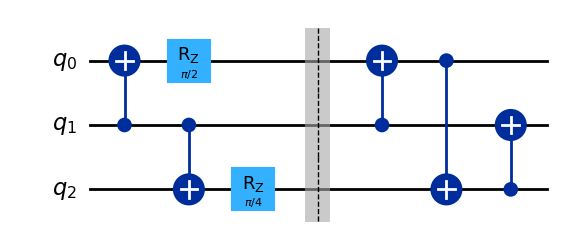

In [5]:
fig3_paths, fig3_circuits = show_doc_pair(3, labels=("(a) lower total cost", "(b) higher total cost"))


In [6]:
fig3_record = verify_doc_pair(3)


qiskit: ok       True  (0.04s)
  qcec: ok       EquivalenceCriterion.equivalent  (0.07s)


## Fig. 4: Cross-block MCX Optimization

Hadamard gates split the MCX fragment into separate phase-polynomial blocks. PhasePoly builds a cross-block IR, reuses parity structure across the barriers, and removes redundant CNOTs while keeping the circuit equivalent.


(a) before qubits=5  ops={'cx': 11, 'rz': 5, 'h': 2, 'barrier': 2}
QASM: docs/fig4_1.qasm


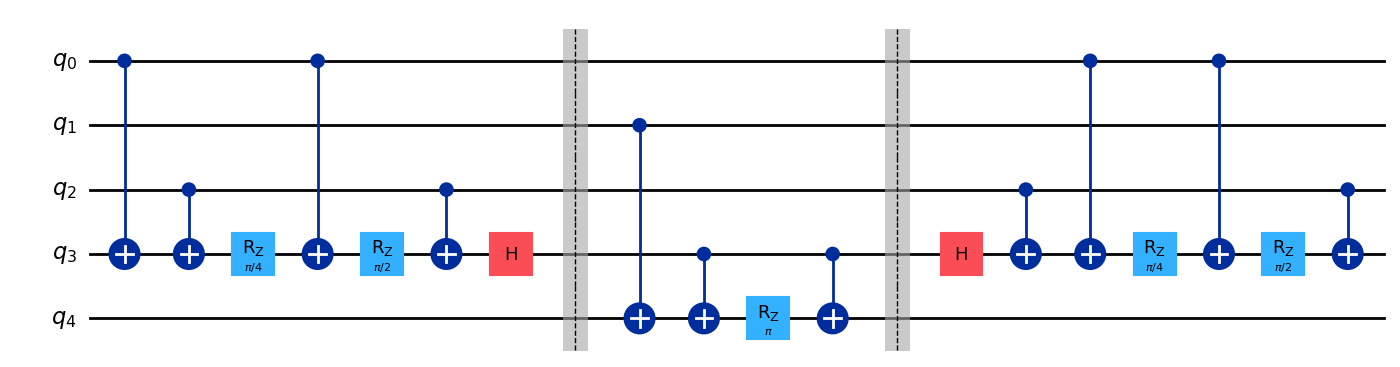

(b) after  qubits=5  ops={'cx': 9, 'rz': 5, 'h': 2, 'barrier': 2}
QASM: docs/fig4_2.qasm


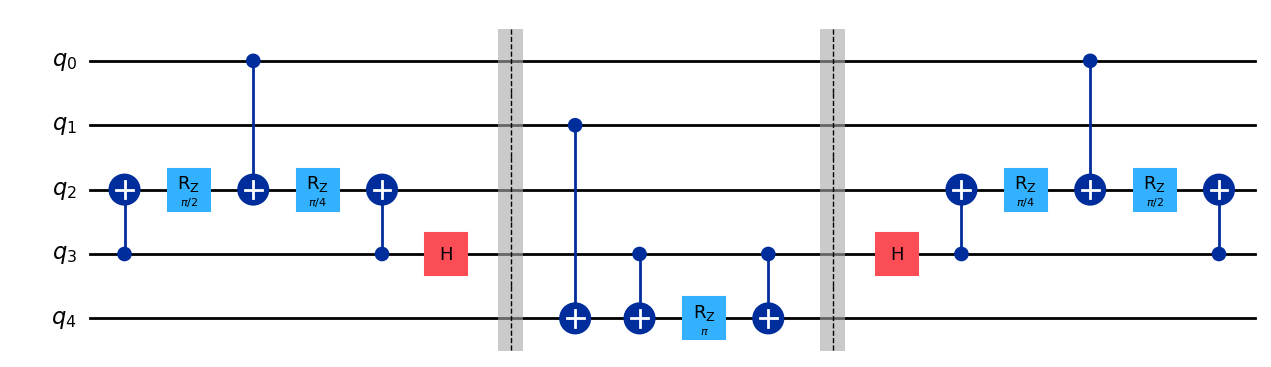

In [7]:
fig4_paths, fig4_circuits = show_doc_pair(4)


In [8]:
fig4_record = verify_doc_pair(4)


qiskit: ok       True  (0.03s)
  qcec: ok       EquivalenceCriterion.equivalent  (0.12s)


## Fig. 9: Cross-block Rewriting Detail

This small example shows the same idea across one `H` barrier. The cross-block IR introduces a new wire view after `H`, keeps the required output parity before the barrier, and then optimizes the merged phase-polynomial region.


(a) before qubits=3  ops={'cx': 5, 'rz': 3, 'barrier': 2, 'h': 1}
QASM: docs/fig9_1.qasm


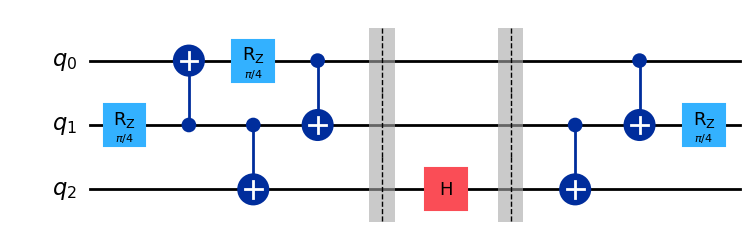

(b) after  qubits=3  ops={'cx': 4, 'rz': 2, 'h': 1}
QASM: docs/fig9_2.qasm


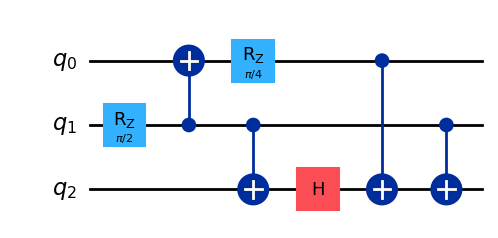

In [9]:
fig9_paths, fig9_circuits = show_doc_pair(9)


In [10]:
fig9_record = verify_doc_pair(9)


qiskit: ok       True  (0.03s)
  qcec: ok       EquivalenceCriterion.equivalent  (0.06s)
